# Interactive Notebook 02 - PWM extensions:

This interactive Jupyter notebook introduces extensions to pulse width modulation, harmonic analysis, and 6-step operation within a three phase voltage-source inverter.

For help with the installation of the required software, consider the comments in ```CTPD_course\interactive_notebooks\README.md```.
Throughout the exercises, we will be using a combination of scientific computation libraries from the [JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) ecosystem and visualize them with [matplotlib](https://matplotlib.org/) and [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/).

### Preliminaries & Imports:

In [ ]:
# automatically reloads imported ```.py```-files once they are changed and saved
%load_ext autoreload
%autoreload 2

In [ ]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
</style>

In [ ]:
# imports required packages
from functools import partial
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
mpl.rcParams.update({'font.size': 20})
import jax
import jax.numpy as jnp

In [ ]:
from analytical_harmonics import build_analytical_spectrum, visualize_analytical_spectrum
from helper_functions import triangular_signal, compute_three_phase_signals, three_phase_plot, plot_fft_spectrum, get_fft_spectrum

(**Optional**: If you have LaTeX installed, you can use the following lines for pretty rendering of plot labels.
Any LaTeX installation should work, as long as all the required packages are installed, e.g., [MiKTeX](https://miktex.org/) or [TeXLive](https://www.tug.org/texlive/).

If you do not have LaTeX installed, you can comment the next cell out or skip it.)

In [ ]:
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

---

### Three-phase harmonics:

In [ ]:
T_full = 0.2 # s
N = 10_000
f_sampling = N / T_full  # 'N' samples per 'T_full' seconds

f_p = 1000  # Hz
T_p = 1 / f_p
t = jnp.linspace(0, T_full, N)
print(t.shape)

In [ ]:
c_t = triangular_signal(t, frequency=f_p, amplitude=1.0, phase=0.0)

u_dc = 20  # V
m = 1.0
f_fundamental = 10  # Hz
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=m, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t)

#### FFT-based harmonics:

We utilize the fast fourier transform (FFT) to compute the spectrum of our signals.

First we consider the spectrum of our reference wave for a sanity check.

In [ ]:
# test FFT settings on single sine wave:
spectrum = jnp.abs(jnp.fft.rfft(s_ref_t[..., 0], axis=0))
freqs = jnp.fft.rfftfreq(N, d=1/f_sampling)
amps  = (2 / N) * jnp.abs(spectrum)

plt.bar(freqs[:150], amps[:150])
plt.xlim(0, 20)
plt.show()

As expected, the only contribution is at the fundamental frequency $f_1 = 10 \, \mathrm{Hz}$.

Next we consider the spectrum of the switching signal $s_\mathrm{a}(t)$:

In [ ]:
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)

and the spectrum of the normalized line-to-line voltage:

$$\frac{u_\mathrm{a-b}(t)}{u_\mathrm{dc} / 2}$$

In [ ]:
# exemplary line-to-line PWM harmonics:
plot_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N, f_fundamental)

#### Comparison of analytical and numeric spectra:

In order to ensure compliance between the FFT and the analytical derivation of the harmonic spectrum for the lecture, the two are compared in the following.

The analytical harmonic frequencies are given as

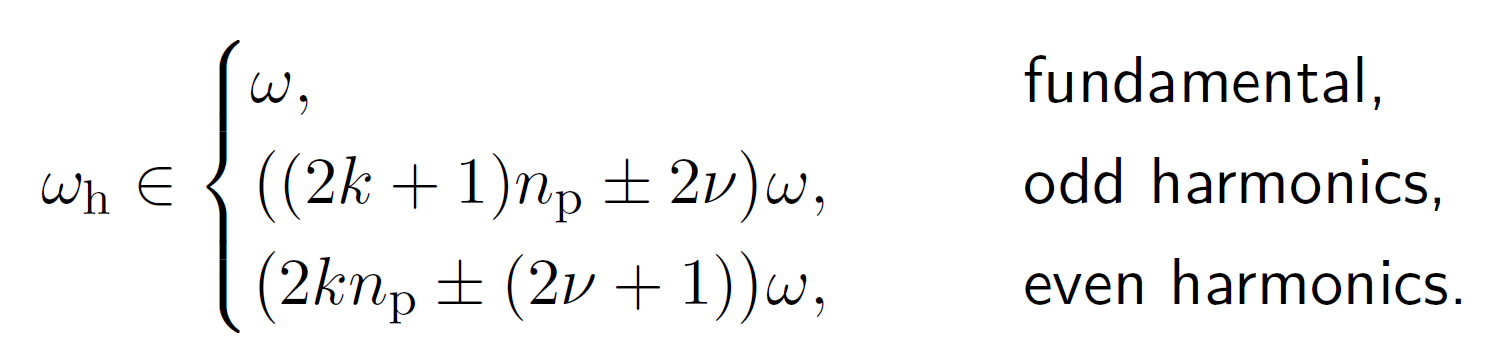

The following plot shows the fundamental frequency at $f/f_1 = 1$, the first odd harmonics at $f/f_1 = 100$ including the sidebands with +- even multiples of $f_1$, and the first even harmonics at $f/f_1 = 200$ including sidebands at +- odd multiples of $f_1$. Not that there is no harmonic content at exactly $f/f_1 = 200$.

In [ ]:
fig, axs = plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)

## 

spectrum = build_analytical_spectrum(
    pulse_number=f_p/f_fundamental,  # 100
    modulation_index=m,
    fundamental_frequency_hz=f_fundamental,  # 10
)

frequencies = []
amplitudes = []
for freq_dict in spectrum:
    frequencies.append(freq_dict["normalized_frequency"])
    amplitudes.append(freq_dict["amplitude"])

for ax in axs:
    ax.bar(frequencies, amplitudes, alpha=0.5)

The FFT-based spectrum fits to the spectrum based on analytical calculations. We will consider only FFT-based spectra in the following.

#### Total harmonic distortion (THD):

The THD measures the ratio of the harmonic contribution of $f_1$ compared to all other harmonic content:

$$\mathrm{THD} = \sqrt{\frac{\sum^{\infty}_{n=3,5,7,\dots} U_n^2}{U_1^2}},$$

where $U_1$ is the amplitude of the fundamental frequency and $U_n$ is the amplitude of the $n$-th harmonic.


**Ist es richtig, dass wir nur ungrade contributions betrachten?**

In [ ]:
def get_amplitude_at_freq(amps, freqs, target_freq):
    idx = jnp.argmin(jnp.abs(freqs - target_freq))
    return amps[idx]

@jax.jit
def compute_THD(amps, freqs, f_fundamental, max_n=300):
    amp_fundamental = get_amplitude_at_freq(amps, freqs, f_fundamental)

    n = jnp.arange(3, max_n, 2)  # all odd numbers from 3 to max_n

    # parallelizes over the target frequencies but not over the other two inputs:
    target_freqs = n * f_fundamental
    amps_harmonic = jax.vmap(get_amplitude_at_freq, in_axes=(None, None, 0))(amps, freqs, target_freqs)

    return jnp.sqrt(jnp.sum(amps_harmonic**2) / amp_fundamental**2)

In [ ]:
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=1, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)

amps, freqs = get_fft_spectrum(s_t[..., 0], f_sampling, N)
compute_THD(amps, freqs, f_fundamental)

#### Effective value (RMS):

**Ich würde hier eigentlich gerne den effektiven Output der PWM vergleichen, um zu zeigen, dass die Verfahren tatsächlich eine Verbesserung liefern. Ich glaube es passt so aber noch nicht richtig oder? Von was müssten wir den Effektivwert berechnen?**

In [ ]:
@jax.jit
def get_effective_value(x_t):
    return jnp.sqrt(jnp.mean(x_t**2))

In [ ]:
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=1.0, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)

get_effective_value(s_t[..., 0] - s_t[..., 1])

### Zero sequence injection:

Allow the extension of the modulation index $m$ from $1$ to $2 / \sqrt{3} \approx 1.155$

with min-max zero-sequence injection:

$$s_0 (t) = \frac{1}{2} (\mathrm{max} \{s^*_{\mathrm{a}}, s^*_{\mathrm{b}}, s^*_{\mathrm{c}}\} + \mathrm{min} \{s^*_{\mathrm{a}}, s^*_{\mathrm{b}}, s^*_{\mathrm{c}}\})$$

In [ ]:
def compute_three_phase_signals_zsi_minmax(m, u_ref_freq, t, c_t, u_dc):

    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    
    s_0_t = 0.5 * (jnp.max(s_ref_t, axis=-1) + jnp.min(s_ref_t, axis=-1))
    s_ref_t = s_ref_t - s_0_t[..., None]
    u_ref_t = u_dc / 2  * s_ref_t
    
    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t, s_0_t

In [ ]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_minmax(
    m=2/jnp.sqrt(3),
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

### Clipping for overmodulation operation:

In [ ]:
def compute_three_phase_signals_zsi_clipping(m, u_ref_freq, t, c_t, u_dc):

    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    
    s_0_t = 1/2 * (jnp.max(s_ref_t, axis=-1) + jnp.min(s_ref_t, axis=-1))
    s_ref_t = jnp.clip(s_ref_t - s_0_t[..., None], min=-1, max=1)
    u_ref_t = u_dc / 2  * s_ref_t
    
    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t, s_0_t

In [ ]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_clipping(
    m=1.24,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

In [ ]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_clipping(
    m=1.24,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)

amps, freqs = get_fft_spectrum(s_t[..., 0], f_sampling, N)
compute_THD(amps, freqs, f_fundamental)

At maximum modulation index: $m = 4/3$.

In [ ]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_clipping(
    m=4/3,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

### 6-step operation:

6-step operation is utilized at the voltage and current limit (generally for maximum speed operation).
Note that for this operation, no PWM is necessary: The switches are operated open-loop solely based on the momentary electrical angle of the machine.

In practice, the electrical angular velcoity is based on the closed loop process, where the motor interacts with the mechanical load to produce the rotation.
Here, we assume a constant electrical angular frequency for simplicity.

In [ ]:
f_el = 25  # Hz
omega_el = 2 * jnp.pi * f_el

In [ ]:
eps_el = (omega_el * t) % (2 * jnp.pi)

sector = (eps_el / (jnp.pi / 3)).astype(int) % 6

switching_table = jnp.array([
    [ 1, -1, -1],
    [ 1,  1, -1],
    [-1,  1, -1],
    [-1,  1,  1],
    [-1, -1,  1],
    [ 1, -1,  1],
])

s_t = switching_table[sector]

In [ ]:
fig_left, axs = plt.subplots(
    6, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2, 1, 1, 1, 1.5]}, constrained_layout=True
)
axs[0].plot(t, eps_el, color="tab:blue")


axs[1].step(t, sector, color="tab:blue")
axs[2].step(t, s_t[..., 0], color="tab:blue")
axs[3].step(t, s_t[..., 1], color="tab:red")
axs[4].step(t, s_t[..., 2], color="black")
axs[5].step(t, (s_t[..., 0] - s_t[..., 1]) / 2, color="tab:orange")


for ax in axs:
    ax.grid(alpha=0.5)
    ax.tick_params(which="major", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")
    ax.set_xlim(t[0], t[-1])


for ax in axs[2:]:
    ax.set_ylim(-1.1, 1.1)

axs[0].set_ylabel("$\\varepsilon_{\\mathrm{el}}$")
axs[1].set_ylabel("sector")
axs[2].set_ylabel("$s_\\mathrm{a}(t)$")
axs[3].set_ylabel("$s_\\mathrm{b}(t)$")
axs[4].set_ylabel("$s_\\mathrm{c}(t)$")
axs[5].set_ylabel("$\\frac{u_\\mathrm{a-b}(t)}{u_\\mathrm{dc}}$")
axs[-1].set_xlabel("$t$ in $s$")

plt.show()

plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_el)
plt.show()

In [ ]:
get_effective_value(s_t[..., 0] - s_t[..., 1])

The theoretical THD for the 6-step operation can be analytically computed with the infinite series (see "Pulse Width Modulation for Power Converters: Principles and Practice" by D. Grahame Holmes and Thomas A. Lipo (2003), pp. 64-65):

$$ \mathrm{THD}_\mathrm{6-step, 1phase} = \sqrt{\sum^\infty_{n=3,5,7,9,11,13,15,17,\dots} \frac{1}{n^2}} \approx 0.4834$$

$$ \mathrm{THD}_\mathrm{6-step, l2l} = \sqrt{\sum^\infty_{n=5,7,11,13,17,\dots} \frac{1}{n^2}} \approx 0.3108$$

In [ ]:
# single phase
amps, freqs = get_fft_spectrum(s_t[..., 0], f_sampling, N)
compute_THD(amps, freqs, f_el)

In [ ]:
# line to line
amps, freqs = get_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N)
compute_THD(amps, freqs, f_el)

The FFT based results are slightly lower than the analytical results.

This is to be expected, since the FFT has a fixed window length and, therefore, the computed THD does not take all harmonic contributions until $\infty$ into account.
Some inaccuracies can also stem from floating point inaccuracies.

### Interactive plot PWM:

Measure the TDD or THD and the output voltages / power, effective voltage value?

In [ ]:
%matplotlib widget

In [ ]:
from helper_functions import InteractivePWMVisualizer

In [ ]:
# setup parameters and carrier signal

T_full = 0.2 # s
N = 10_000
f_sampling = N / T_full  # 'N' samples per 'T_full' seconds

f_p = 1000  # Hz
T_p = 1 / f_p
t = jnp.linspace(0, T_full, N)

u_dc = 20  # V
print(t.shape)

There are two unsolved issues for this visualization:
- If the full left half of the plot is not showing up, rerun the cell.
- If some part of the plot is not showing, slightly resizing the window for the left plot usually fixes the issue.

In [ ]:
plt.close('all')
plt.ioff()

visualizer = InteractivePWMVisualizer(
    t,
    c_t,
    u_dc,
    compute_three_phase_signals=jax.jit(compute_three_phase_signals),
    compute_three_phase_signals_zsi_minmax=jax.jit(compute_three_phase_signals_zsi_minmax),
    compute_three_phase_signals_zsi_clipping=jax.jit(compute_three_phase_signals_zsi_clipping),
)

display(visualizer.ui, visualizer.out)

In [ ]:
raise

# FFT Harmonics for test bench task:

In [ ]:
# T_full = 0.04 # s
# N = 20_000
# f_sampling = N / T_full  # 'N' samples per 'T_full' seconds

# f_fundamental = 50

# f_p = 8000  # Hz
# T_p = 1 / f_p
# t = jnp.linspace(0, T_full, N)
# print(t.shape)

# c_t = triangular_signal(t, frequency=f_p, amplitude=1.0, phase=0.0)


# u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_minmax(
#     m=1,
#     u_ref_freq=f_fundamental,
#     t=t,
#     c_t=c_t,
#     u_dc=u_dc
# )
# fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
# plt.show()

# amps, freqs = get_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N)

In [ ]:
# fig, axs = plt.subplots(4, 1, figsize=(10, 8), constrained_layout=True)

# for ax in axs:
#     ax.set_ylabel("$\\hat{s}$")
#     ax.grid(alpha=0.5)
#     ax.tick_params(which="major", axis="y", direction="in")
#     ax.tick_params(which="both", axis="x", direction="in")

# axs[0].bar(freqs[:2500] / f_fundamental, amps[:2500])
# axs[0].set_xlim(0, 300)

# axs[1].bar(freqs[:2500] / f_fundamental, amps[:2500])
# axs[1].set_xlim(150, 180)

# axs[2].bar(freqs[:2500] / f_fundamental, amps[:2500])
# axs[2].set_xlim(300, 340)

# axs[-1].bar(freqs[:100] / f_fundamental, amps[:100])
# axs[-1].set_xlim(0, 15)
# axs[-1].set_yscale("log")
# axs[-1].set_xlabel("$f / f^*$")

# plt.show()

In [ ]:
# print(get_amplitude_at_freq(amps, freqs, target_freq=f_fundamental))

In [ ]:
# print(get_amplitude_at_freq(amps, freqs, target_freq=f_p))
# print(get_amplitude_at_freq(amps, freqs, target_freq=f_p-2*f_fundamental))
# print(get_amplitude_at_freq(amps, freqs, target_freq=f_p+2*f_fundamental))

In [ ]:
# print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p))
# print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p-f_fundamental))
# print(get_amplitude_at_freq(amps, freqs, target_freq=2*f_p+f_fundamental))